# Interaction between Spending and other factors 
**Van Ha TRAN** 

This project explores the drivers of customer spending behavior using a marketing campaign dataset. The central question is: **what factors explain why some customers spend significantly more than others?**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
df = pd.read_excel('Customer_marketing_dataset.xlsx', sheet_name='marketing_campaign')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (2240, 24)
Columns: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,3,8,10,4,7,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,1,2,5,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,1,8,2,10,4,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,2,2,0,4,6,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,5,3,6,5,0,0,0,0,0


**Description:**

| Group | Variable | Introduction |
|---|---|---|
| Demographics | `Year_Birth`, `Education`, `Marital_Status`, `Income`, `Kidhome`, `Teenhome` |  |
| Spending | `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts` | Spending in each category |
| Behavior | `NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases`, `NumDealsPurchases` | Spending behavior |
| Campaign | `AcceptedCmp1/2/3`, `Response` | Response to marketing campaign |

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Missing values:')
print(missing)

Missing values:
Income    24
dtype: int64


In [4]:
df = df.dropna(subset=['Income'])
print(f'\nMissing after: {df.isnull().sum().sum()}')
print(f'Remaining column: {len(df)}')


Missing after: 0
Remaining column: 2216


In [5]:
# Total spending 
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts','MntFishProducts', 'MntSweetProducts']
df['TotalSpending'] = df[spending_cols].sum(axis=1)

# Age
df['Age'] = 2026 - df['Year_Birth']

# Children 
df['Children'] = df['Kidhome'] + df['Teenhome']

# Total purchase 
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases',
                 'NumStorePurchases']
df['TotalPurchases'] = df[purchase_cols].sum(axis=1)

# Family size
df['FamilySize'] = (1 + df['Marital_Status'].isin(['Married', 'Together']).astype(int)
    + df['Kidhome']+ df['Teenhome'])

print(df[['TotalSpending', 'Age', 'Children', 'TotalPurchases','FamilySize']].describe().round(1))

       TotalSpending     Age  Children  TotalPurchases  FamilySize
count         2216.0  2216.0    2216.0          2216.0      2216.0
mean           563.1    57.2       0.9            12.6         2.6
std            577.2    12.0       0.7             7.2         0.9
min              4.0    30.0       0.0             0.0         1.0
25%             55.0    49.0       0.0             6.0         2.0
50%            342.5    56.0       1.0            12.0         3.0
75%            964.0    67.0       1.0            18.0         3.0
max           2491.0   133.0       3.0            32.0         5.0


In [6]:
df = df[df['Age'] <= 100]
df = df[df['Income'] <= 600000]

In [7]:
df[['Age', 'Income', 'TotalSpending', 'TotalPurchases', 'Children']].describe().round(2)

,Age,Income,TotalSpending,TotalPurchases,Children
count,2212.00,2212.00,2212.00,2212.00,2212.00
mean,57.09,51958.81,563.34,12.57,0.95
std,11.70,21527.28,576.93,7.21,0.75
min,30.00,1730.00,4.00,0.00,0.00
25%,49.00,35233.50,55.75,6.00,0.00
50%,56.00,51371.00,343.00,12.00,1.00
75%,67.00,68487.00,964.00,18.25,1.00
max,86.00,162397.00,2491.00,32.00,3.00


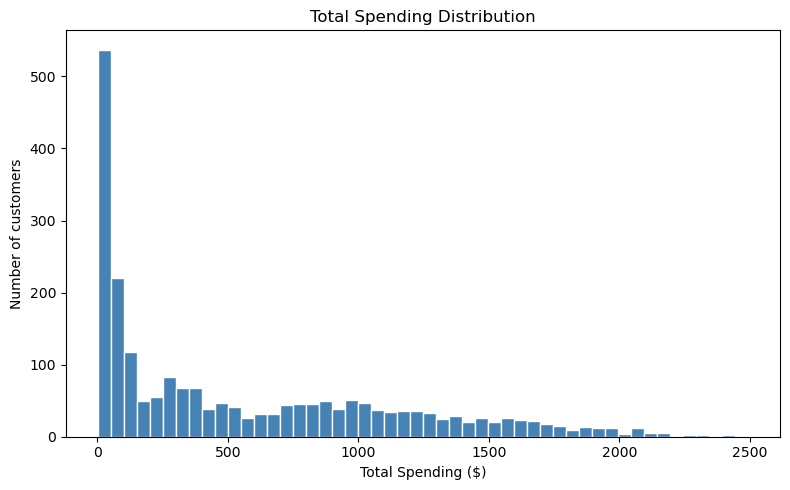

Mean: $563
Median  : $343
Skewness  : 0.914


In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df['TotalSpending'], bins=50, color='steelblue', edgecolor='white')
plt.title('Total Spending Distribution')
plt.xlabel('Total Spending ($)')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

print(f'Mean: ${df["TotalSpending"].mean():.0f}')
print(f'Median  : ${df["TotalSpending"].median():.0f}')
print(f'Skewness  : {df["TotalSpending"].skew():.3f}')

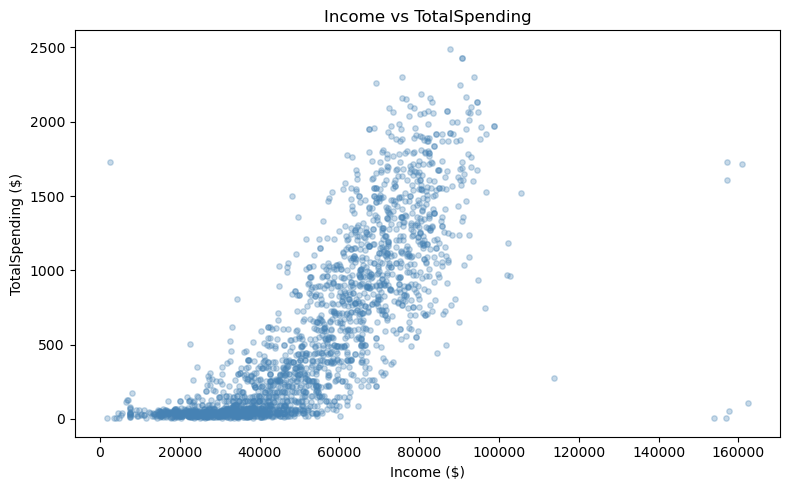

Correlation: 0.793


In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Income'], df['TotalSpending'], alpha=0.3, s=15, color='steelblue')
plt.xlabel('Income ($)')
plt.ylabel('TotalSpending ($)')
plt.title('Income vs TotalSpending')
plt.tight_layout()
plt.show()

corr_income = df['Income'].corr(df['TotalSpending'])
print(f'Correlation: {corr_income:.3f}')

In [10]:
# Group `Education`
df['Education_grouped'] = df['Education'].map({
    'Basic'      : 'Low',
    '2n Cycle'   : 'Low',
    'Graduation' : 'High',
    'Master'     : 'High',
    'PhD'        : 'High'
})

print(df['Education_grouped'].value_counts())


Education_grouped
High    1960
Low      252
Name: count, dtype: int64


In [11]:
df_model = pd.get_dummies(df, 
                          columns=['Education_grouped'], 
                          drop_first=True).astype({col: int for col in pd.get_dummies(df, columns=['Education_grouped'], drop_first=True).select_dtypes('bool').columns})

edu = [c for c in df_model.columns if c.startswith('Education_grouped_')]


behavior_vars = ['NumWebPurchases', 'NumCatalogPurchases',
                 'NumStorePurchases', 'Recency']

y = df_model['TotalSpending']


In [12]:
# Model 1 — Income only
X1 = sm.add_constant(df_model[['Income']])
model1 = sm.OLS(y, X1).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          TotalSpending   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     3747.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:49:26   Log-Likelihood:                -16105.
No. Observations:                2212   AIC:                         3.221e+04
Df Residuals:                    2210   BIC:                         3.223e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -541.0331     19.529    -27.704      0.000    -579.330    -502.736
Income         0.0213      0.000     61.210      0.000       0.021       0.022
==============================================================================
Omnibus:                      375.732   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5435.493
Skew:                          -0.329   Prob(JB):                         0.00
Kurtosis:                      10.651   Cond. No.                     1.47e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.47e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interprete:** Income alone explains 62.9% of the variance in total spending, making it by far the strongest single predictor. The coefficient of 0.0213 indicates that each additional dollar of income is associated with approximately $0.021 in additional spending. 

In [13]:
# Model 2 — + Family size, Age
X2 = sm.add_constant(df_model[['Income', 'FamilySize', 'Age']])
model2 = sm.OLS(y, X2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          TotalSpending   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     1498.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:49:26   Log-Likelihood:                -15973.
No. Observations:                2212   AIC:                         3.195e+04
Df Residuals:                    2208   BIC:                         3.198e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -72.4221     42.583     -1.701      0.089    -155.929      11.085
Income         0.0197      0.000     56.127      0.000       0.019       0.020
FamilySize  -133.7428      8.203    -16.303      0.000    -149.830    -117.656
Age           -0.7377      0.621     -1.188      0.235      -1.956       0.480
==============================================================================
Omnibus:                      400.463   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6183.545
Skew:                          -0.376   Prob(JB):                         0.00
Kurtosis:                      11.156   Cond. No.                     3.42e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.42e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interprete:** Adding FamilySize and Age improves R² by 4.2 percentage points. FamilySize is highly significant (coef = −133.74, p < 0.001): each additional household member is associated with $133.74 less in total spending, likely reflecting budget constraints in larger households. Age, however, is not statistically significant (p = 0.235), suggesting that age alone does not independently explain spending differences once income and family size are controlled for.

In [14]:
# Model 3 — + Education, Marital Status
X3 = sm.add_constant(df_model[['Income', 'FamilySize', 'Age'] + edu])
model3 = sm.OLS(y, X3).fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          TotalSpending   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     1123.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:49:26   Log-Likelihood:                -15973.
No. Observations:                2212   AIC:                         3.196e+04
Df Residuals:                    2207   BIC:                         3.199e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -68.3177     43.933     -1.555      0.120    -154.472      17.836
Income                    0.0197      0.000     55.361      0.000       0.019       0.020
FamilySize             -133.9444      8.222    -16.291      0.000    -150.068    -117.821
Age                      -0.7638      0.625     -1.222      0.222      -1.990       0.462
Education_grouped_Low    -8.6542     22.717     -0.381      0.703     -53.202      35.894
==============================================================================
Omnibus:                      399.736   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6154.918
Skew:                          -0.375   Prob(JB):                         0.00
Kurtosis:                      11.137   Cond. No.                     3.56e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.56e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interprete:** Adding education level produces no improvement in R² (remains at 0.671). The coefficient on Education_grouped_Low is −8.65 but statistically insignificant (p = 0.703)

In [15]:
# Model 4 — Full model
X4 = sm.add_constant(df_model[['Income', 'Children', 'Age'] + edu + behavior_vars])
model4 = sm.OLS(y, X4).fit()
model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          TotalSpending   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     1011.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:49:26   Log-Likelihood:                -15496.
No. Observations:                2212   AIC:                         3.101e+04
Df Residuals:                    2203   BIC:                         3.106e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  -191.4423     33.397     -5.732      0.000    -256.935    -125.950
Income                    0.0094      0.000     22.288      0.000       0.009       0.010
Children               -121.7877      8.728    -13.954      0.000    -138.904    -104.672
Age                      -1.3337      0.508     -2.624      0.009      -2.331      -0.337
Education_grouped_Low   -34.6385     18.377     -1.885      0.060     -70.676       1.399
NumWebPurchases          25.3301      2.491     10.169      0.000      20.446      30.215
NumCatalogPurchases      64.8536      2.869     22.608      0.000      59.228      70.479
NumStorePurchases        29.8569      2.425     12.314      0.000      25.102      34.612
Recency                   0.2573      0.197      1.308      0.191      -0.128       0.643
==============================================================================
Omnibus:                      269.738   Durbin-Watson:                   2.012
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1115.524
Skew:                           0.533   Prob(JB):                    5.85e-243
Kurtosis:                       6.312   Cond. No.                     3.35e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interprete:** NumCatalogPurchases (coef = 64.85, p < 0.001) and NumStorePurchases (coef = 29.86, p < 0.001) are the most impactful behavioral variables, each additional catalog purchase is associated with $64.85 more in spending. NumWebPurchases is also significant (p < 0.001). Recency, however, is not significant (p = 0.191), suggesting that how recently a customer last purchased does not predict their total spending level.

In [16]:
# Model 5 — + AcceptedCmp1, AcceptedCmp2, AcceptedCmp3
campaign_vars = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3']

X5 = sm.add_constant(df_model[['Income', 'FamilySize'] + campaign_vars])
model5 = sm.OLS(y, X5).fit()
model5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          TotalSpending   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     959.3
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:49:26   Log-Likelihood:                -15924.
No. Observations:                2212   AIC:                         3.186e+04
Df Residuals:                    2206   BIC:                         3.189e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         -103.9510     31.463     -3.304      0.001    -165.651     -42.251
Income           0.0187      0.000     53.378      0.000       0.018       0.019
FamilySize    -126.8245      7.985    -15.883      0.000    -142.483    -111.166
AcceptedCmp1   254.8853     30.394      8.386      0.000     195.282     314.488
AcceptedCmp2   157.5496     60.731      2.594      0.010      38.454     276.646
AcceptedCmp3    81.4430     26.588      3.063      0.002      29.303     133.583
==============================================================================
Omnibus:                      379.837   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5270.409
Skew:                          -0.363   Prob(JB):                         0.00
Kurtosis:                      10.527   Cond. No.                     4.97e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.97e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interprete:** All three campaign variables are statistically significant. AcceptedCmp1 has the largest effect (coef = 254.89, p < 0.001): customers who accepted campaign 1 spend on average $254.89 more than those who did not. AcceptedCmp2 (coef = 157.55, p = 0.010) and AcceptedCmp3 (coef = 81.44, p = 0.002) also show positive and significant effects, though of decreasing magnitude. The R² of 0.685 (vs. 0.671 in Model 2) suggests that campaign responsiveness adds meaningful but moderate explanatory power beyond demographics alone.

# Overall Conclusion
Across five nested OLS models, three key findings emerge.

First, income and family size are the dominant structural predictors of spending. Income alone accounts for 62.9% of variance, and FamilySize adds a further 4.2 points. These two variables form a stable core across all models — their coefficients remain significant and consistent in sign throughout, suggesting robust and reliable relationships.

Second, education level does not independently predict spending. Once income is controlled for, the education effect disappears entirely, consistent with the interpretation that education influences spending only indirectly through its effect on income.

Third, purchase behavior is the most informative additional dimension. Model 4 achieves the highest explanatory power (R² = 0.786), driven by catalog and store purchase frequency. This suggests that how customers shop not just their demographic profile is strongly tied to how much they spend overall.

On campaign responsiveness, Model 5 shows that customers who accepted past campaigns spend significantly more, particularly for Campaign 1. This could reflect either a causal effect (campaigns stimulate spending) or selection (higher-spending customers are more likely to engage with campaigns). 